**Project Name :** Hotel Booking Aanalysis


#**Data Overview**

### Import Libraries

In [200]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [201]:
df=pd.read_csv("/content/Hotel Bookings.csv")

In [202]:
df.shape

(119390, 32)

Looking First 5 rows in the dataset

In [203]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Looking Last 5 rows in the dataset

In [204]:
df.tail(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


Dataset Rows and Columns

In [205]:
print(f"Number of rows : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Number of rows : 119390
Number of columns : 32


### Dataset Information

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Duplicate Values

In [207]:
df.duplicated().sum()

np.int64(31994)

Dropping the duplicate values

In [208]:
df.drop_duplicates(inplace=True)

In [209]:
print("After removing Duplicates--")
print(f"Number of rows : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

After removing Duplicates--
Number of rows : 87396
Number of columns : 32


### Missing Values or Null values

In [210]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


**Visualize**

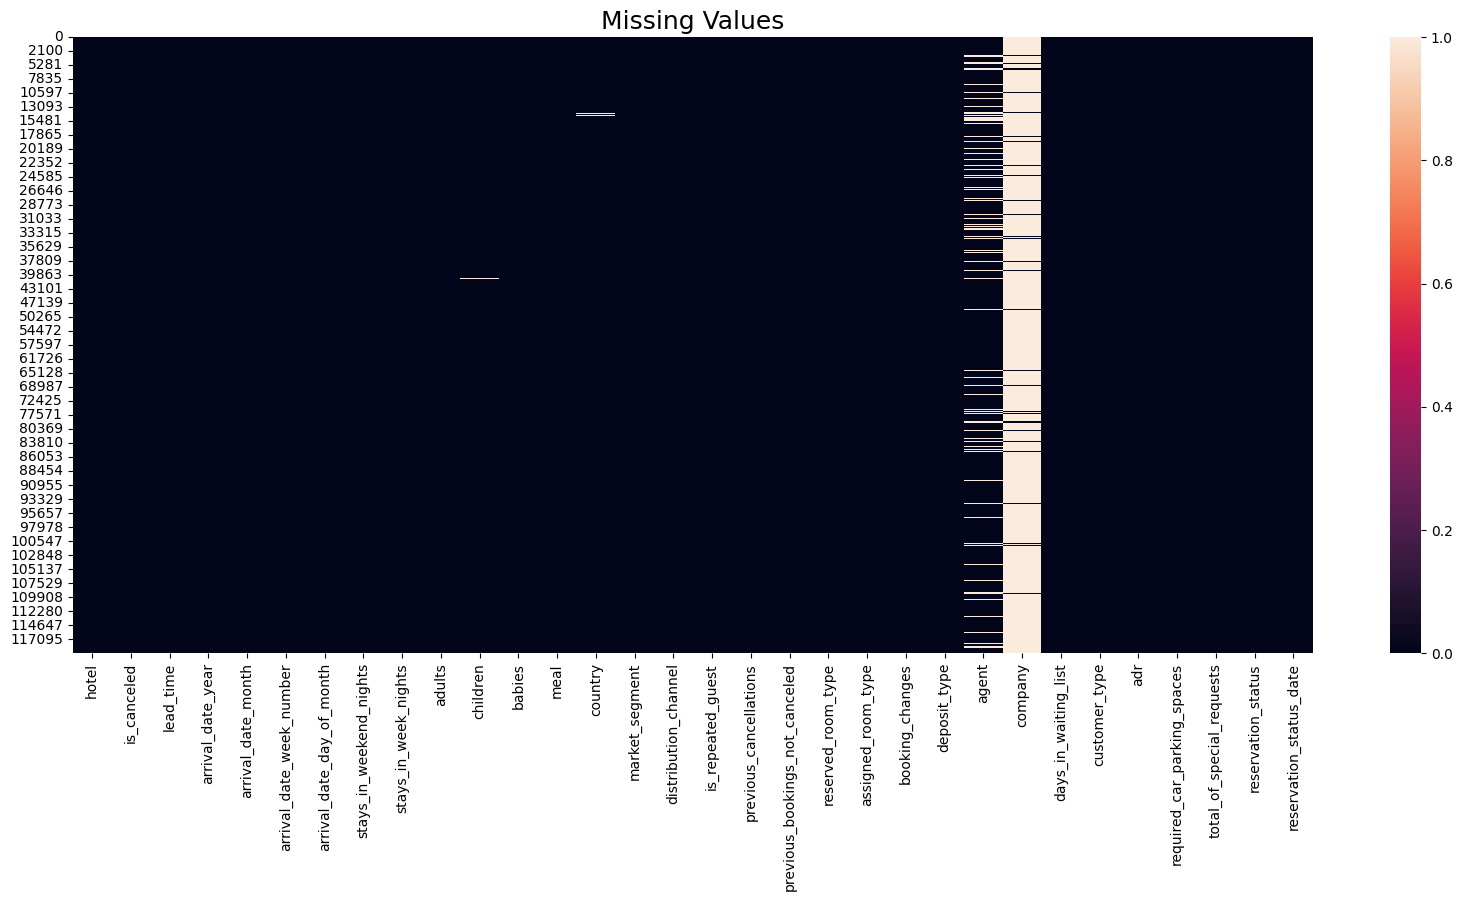

In [211]:
plt.figure(figsize=(20,8))
sns.heatmap(df.isnull())
plt.title('Missing Values',fontsize=18)
plt.show()

We can see that there are total four columns with missing/null values : **company,agent,country,children**

1. In children column, I will replace null values with 0, assumming that customer did not have any children
2. In country column, I will replace null values with **'others'**,assumig that they didn't mentioned country's name while booking
3. In company and agent column is null when customer did not book hotel through them.As these 2 columns have numeric data in it , I will replace null values with 0

###All columns Name

In [212]:
df.columns.to_list()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

**dataset Describe**

In [213]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87392.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,75203.000000,5259.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138640,0.010824,0.039075,0.030413,0.183990,0.271603,94.138306,183.081384,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455881,0.113597,0.193775,0.369145,1.731894,0.727245,113.188172,130.557608,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,47.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,169.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,263.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [214]:
print("Summary Statistics For Categorical Columns\n")
df.describe(include='object')

Summary Statistics For Categorical Columns



,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,87396,87396,87396,86944,87396,87396,87396,87396,87396,87396,87396,87396
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2016-02-14
freq,53428,11257,67978,27453,51618,69141,56552,46313,86251,71986,63371,211


### Check unique values for Categorical columns

In [215]:
def unique_value(col):
  print(f'Column Name: {col}')
  print(df[col].unique())
  print("="*50)
  print("")
cols=df.select_dtypes(include=['object','category']).columns[:-1].tolist()
for col in cols:
  unique_value(col)

Column Name: hotel
['Resort Hotel' 'City Hotel']

Column Name: arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']

Column Name: meal
['BB' 'FB' 'HB' 'SC' 'Undefined']

Column Name: country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 'SYR' 'SGP' 'BDI'
 'SAU' 'VNM' 'PLW' 'QAT' 'EGY' 'PER' 'MLT' 'MWI' 'ECU' 'MDG' 'ISL' 'UZB'
 'N

## **Data Wrangling**

Creating duplicate of the original dataset before making any change

In [216]:
df1=df.copy()

In [217]:
df1.shape

(87396, 32)

### fill the null values

In [218]:
df1['children'].fillna(0,inplace=True)
df1['company'].fillna(0,inplace=True)
df1['agent'].fillna(0,inplace=True)
df1['country'].fillna('Others',inplace=True)

In [219]:
df1.isnull().sum().sum()

np.int64(0)

### Dropping rows where no adults,children and babies are avaiable because no Bookings were made that day

In [220]:
no_guest=df1[df1['adults']+df1['babies']+df1['children']==0]

In [221]:
df1.drop(no_guest.index,inplace=True)

### Adding Some New columns

Creating Total People column by adding all the people

In [222]:
df1['total_people']=df1['adults']+df1['children']+df1['babies']

Creating total stay column

In [223]:
df1['total_stay']=df1['stays_in_weekend_nights']+df1['stays_in_week_nights']

In [224]:
df1.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_people,total_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2.0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1.0,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2.0,2


In [225]:
df1.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_people,total_stay
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0.0,0,Transient,96.14,0,0,Check-Out,2017-09-06,2.0,7
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0.0,0,Transient,225.43,0,2,Check-Out,2017-09-07,3.0,7
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0.0,0,Transient,157.71,0,4,Check-Out,2017-09-07,2.0,7
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0.0,0,Transient,104.40,0,0,Check-Out,2017-09-07,2.0,7
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,0.0,0,Transient,151.20,0,2,Check-Out,2017-09-07,2.0,9


## **EDA**

### **Which type of hotel is most preffered by the guests?**

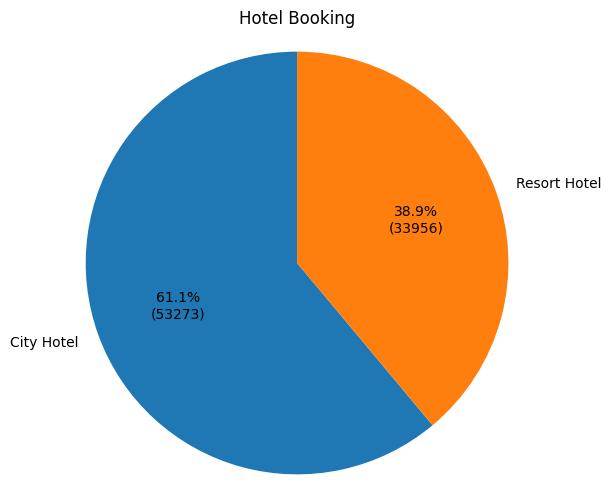

In [226]:
hotel_count = df1['hotel'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    hotel_count,
    labels=hotel_count.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*hotel_count.sum()/100)})',
    startangle=90
)

plt.title("Hotel Booking")
plt.axis('equal')
plt.show()



---
Guest Prefer City Hotel


---
This insight is useful for the stakeholder to check which hotel performs best and they can invest that hotel.Stackholders must focus on city hotel to get more booking and increase the overall revenue




### **What is the percentage of hotel booking cancellation?**

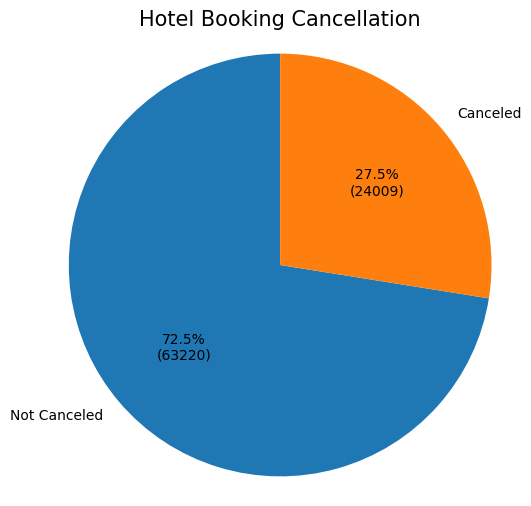

In [227]:
plt.figure(figsize=(6,6))
cancelled_hotel=df1['is_canceled'].value_counts().reset_index()
plt.pie(
    cancelled_hotel['count'],
    labels=cancelled_hotel['is_canceled'].map({1: 'Canceled', 0: 'Not Canceled'}),
    autopct=lambda p: f'{p:.1f}%\n({int(p*cancelled_hotel["count"].sum()/100)})',
    startangle=90
)

plt.title("Hotel Booking Cancellation",fontsize=15)
plt.axis('equal')
plt.show()




---
We are see that around 72.5% bookings are not canceled by guest but around 27.5% bookings are canceled

---
This insight helps stackholders in comparing the cancallation and non-cancellation of bookings.With the help of this inshights stackholders can set a flexiable cancellation policy to reduce booking cancellation



### **Canceled and non canceled Bookings By Hotel Type**

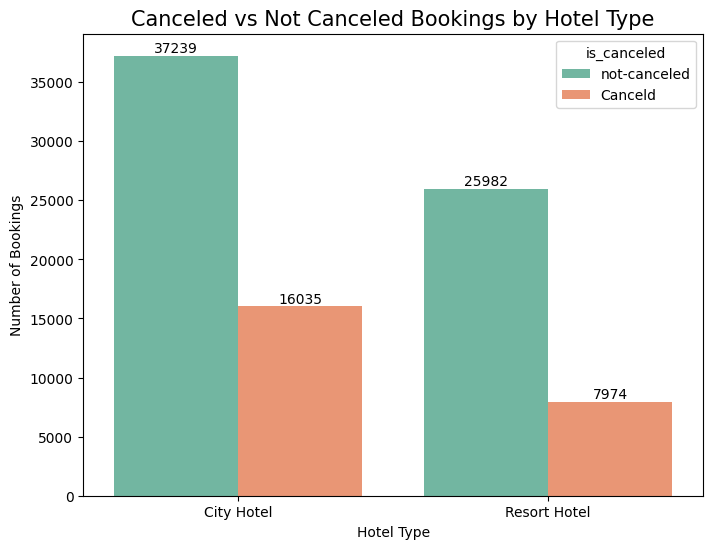

In [228]:
cancel_nonCanceledBookings_by_hotel_type=df1.groupby('hotel',as_index=False)['is_canceled'].value_counts()
# rename columns
cancel_nonCanceledBookings_by_hotel_type.columns=['hotel','is_canceled','count']

cancel_nonCanceledBookings_by_hotel_type['is_canceled']=cancel_nonCanceledBookings_by_hotel_type['is_canceled'].map({1:'Canceld',0:'not-canceled'})

fig,ax=plt.subplots(figsize=(8,6))
sns.barplot(data=cancel_nonCanceledBookings_by_hotel_type,
            x='hotel',
            y='count',
            hue='is_canceled',
            palette='Set2')
for container in ax.containers:
  ax.bar_label(container)

plt.title("Canceled vs Not Canceled Bookings by Hotel Type",fontsize=15)
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

Calculate Cancellation percentage for City Hotel

In [229]:
city_hotel=df1[df1['hotel']=='City Hotel']
print(city_hotel['is_canceled'].value_counts(normalize=True)*100)

is_canceled
0    69.90089
1    30.09911
Name: proportion, dtype: float64


Calculate Cancellation percentage of Resort Hotel

In [230]:
resort_hotel=df1[df1['hotel']=='Resort Hotel']
print(resort_hotel['is_canceled'].value_counts(normalize=True)*100)

is_canceled
0    76.516669
1    23.483331
Name: proportion, dtype: float64


### **Which type of meal is most preffered by guests?**

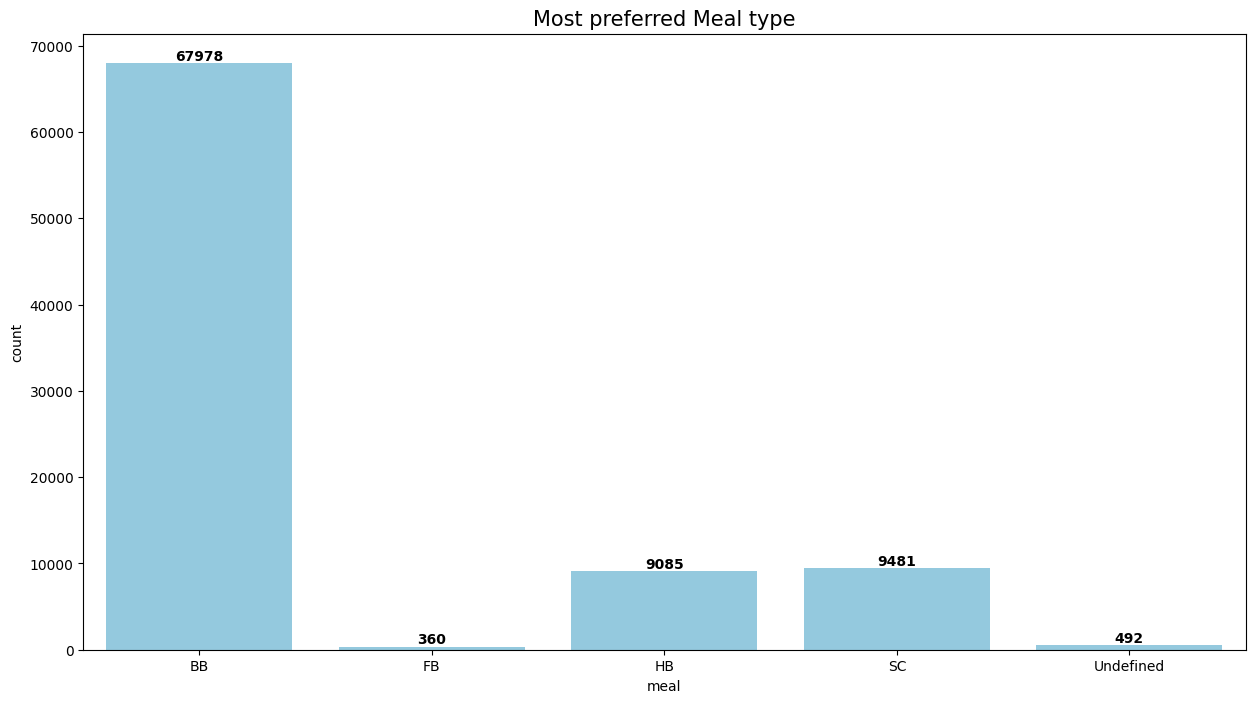

In [231]:
fig,ax=plt.subplots(figsize=(15,8))
sns.countplot(x=df['meal'],color='skyblue')
for container in ax.containers:
  ax.bar_label(container,fontsize=10,fontweight='bold')
plt.title('Most preferred Meal type',fontsize=15)
plt.show()




---
After visualizing the above chart we can see that BB-(Bed and Breakfast) is the most preffered meal type by guests



### **Which year has the most bookings?**

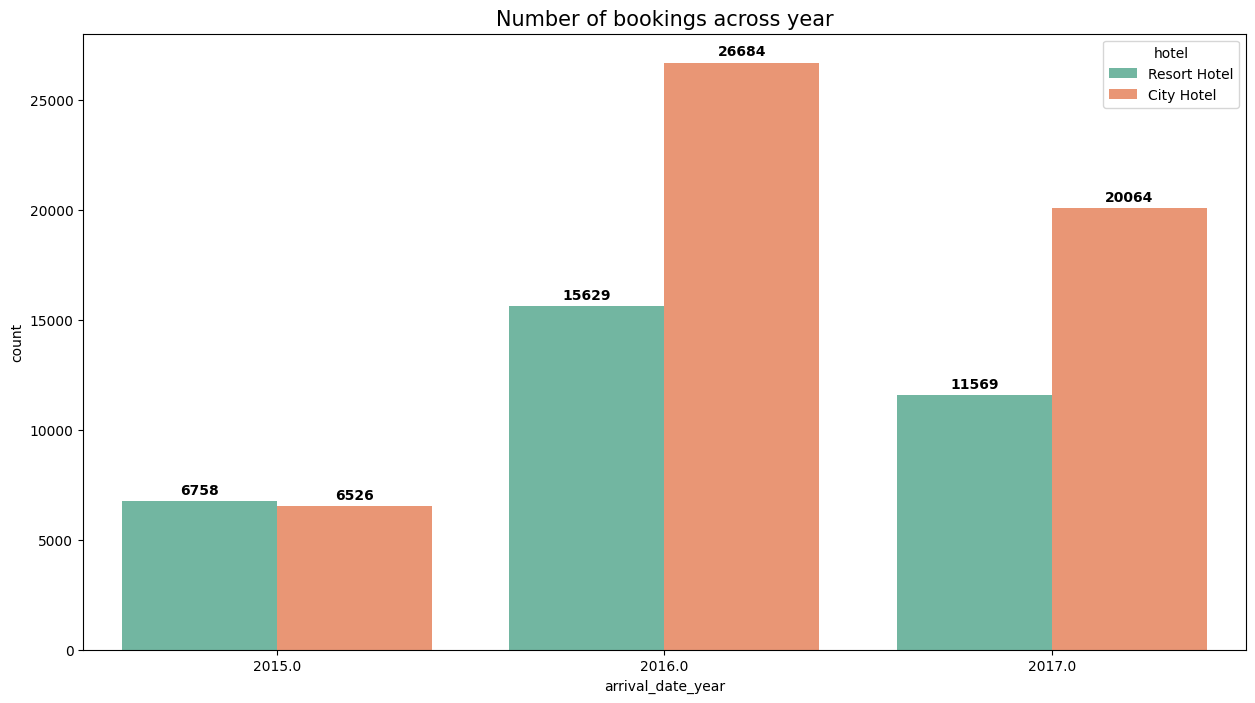

In [232]:
fig,ax=plt.subplots(figsize=(15,8))
sns.countplot(x=df1['arrival_date_year'],
              hue=df['hotel'],
              palette='Set2')
for container in ax.containers:
  ax.bar_label(container,fontsize=10,fontweight='bold',padding=3)
plt.title("Number of bookings across year", fontsize = 15)
plt.show()




---
Hotel was booked most times in year 2016


---
Above this insights shows that booking drop year 2017 compare to year 2016.Stackholders can now find what went wrong after 2016 and fix the problem to increase bookings.One way to do this ask for feedbacks from guests





### **Which month has the most bookings in each hotel type?**

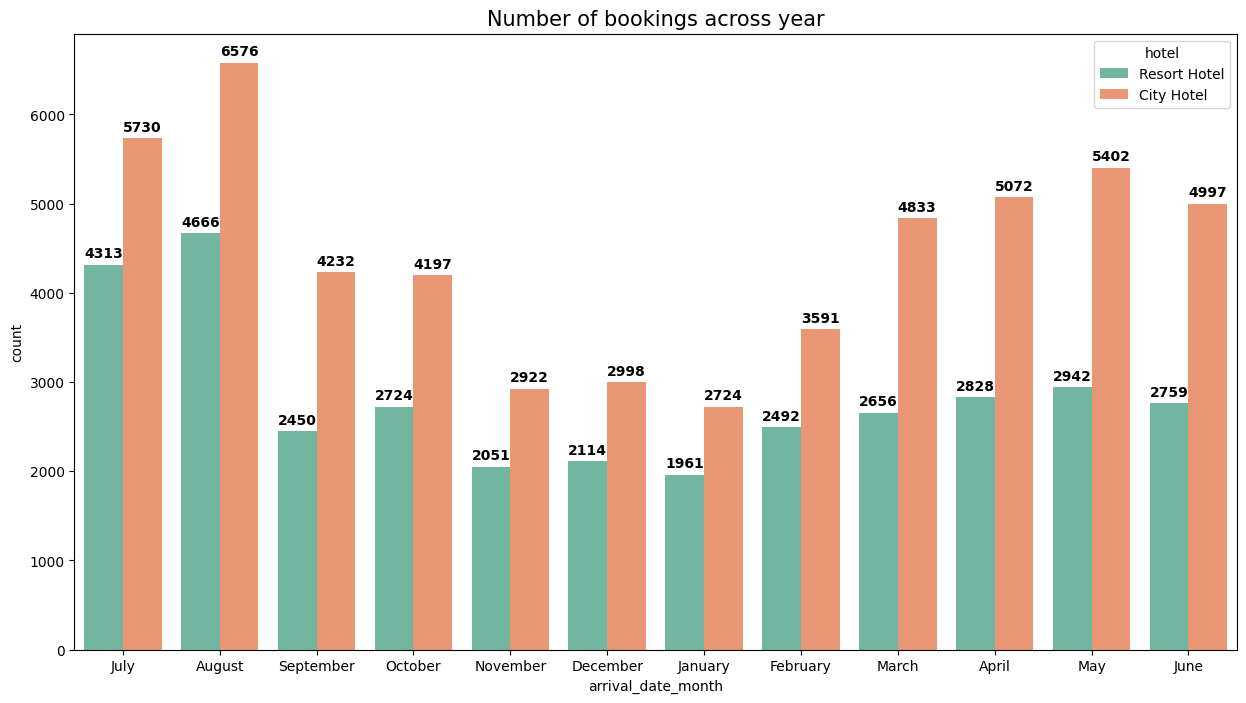

In [233]:
fig,ax=plt.subplots(figsize=(15,8))
sns.countplot(x=df1['arrival_date_month'],
              hue=df['hotel'],
              palette='Set2')
for container in ax.containers:
  ax.bar_label(container,fontsize=10,fontweight='bold',padding=3)
plt.title("Number of bookings across year", fontsize = 15)
plt.show()


---
The graph shows that Agust and July is the most booking month compare to other months



### **From which country most guests come?**

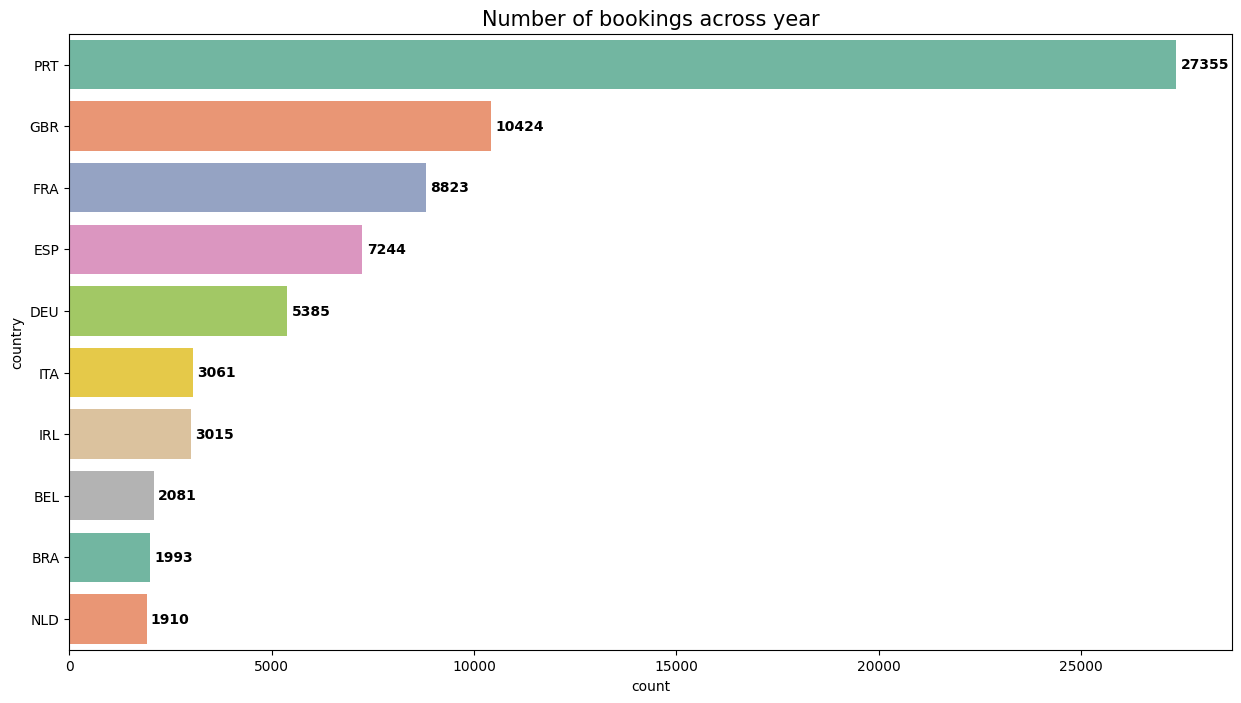

In [234]:
country_top10=df1['country'].value_counts(ascending=False).head(10).reset_index()
fig,ax=plt.subplots(figsize=(15,8))

sns.barplot(data=country_top10,
            y='country',
            x='count',
            hue='country',
            palette='Set2')

for container in ax.containers:
  ax.bar_label(container,fontsize=10,fontweight='bold',padding=3)
plt.title("Number of bookings across year", fontsize = 15)
plt.show()



---
the chart shows that most guests are come from PRT(Portugal)

---
From this insights hotel can add more portugal cusine in their food menu to make guests order more food


### **Which distribution channel is most used in booking?**

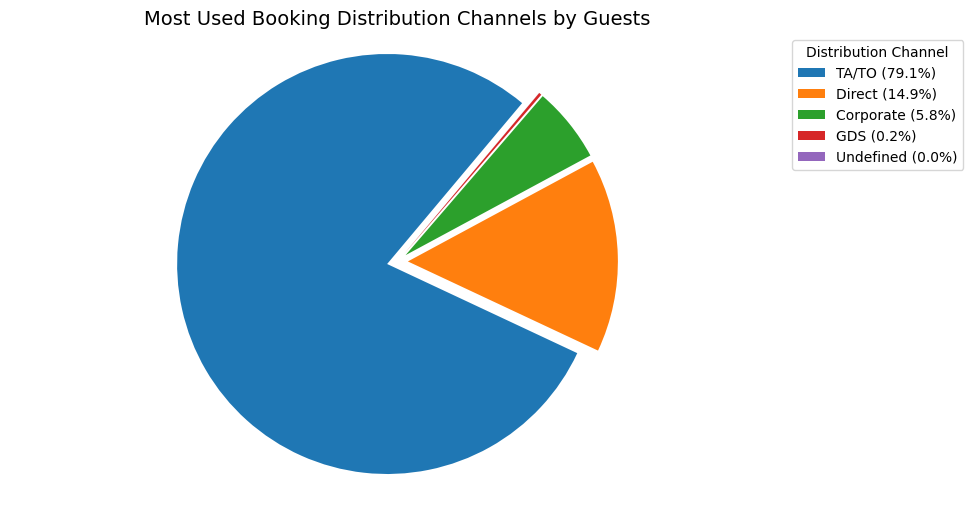

In [235]:
dist_df =df1['distribution_channel'].value_counts()
explode = [0.05] * len(dist_df)
plt.figure(figsize=(10,6))

plt.pie(
    dist_df.values,
    explode=explode,
    startangle=50
)

labels = [
    f"{name} ({count/dist_df.sum()*100:.1f}%)"
    for name, count in dist_df.items()
]

plt.legend(
    labels,
    title="Distribution Channel",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

plt.title("Most Used Booking Distribution Channels by Guests", fontsize=14)
plt.axis('equal')
plt.show()




---
From the above chart it is clear that TA/TO (Travel Agents/Tour Operators) is most used distribution channel by guests


### **Which room type is most preffered by guests?**

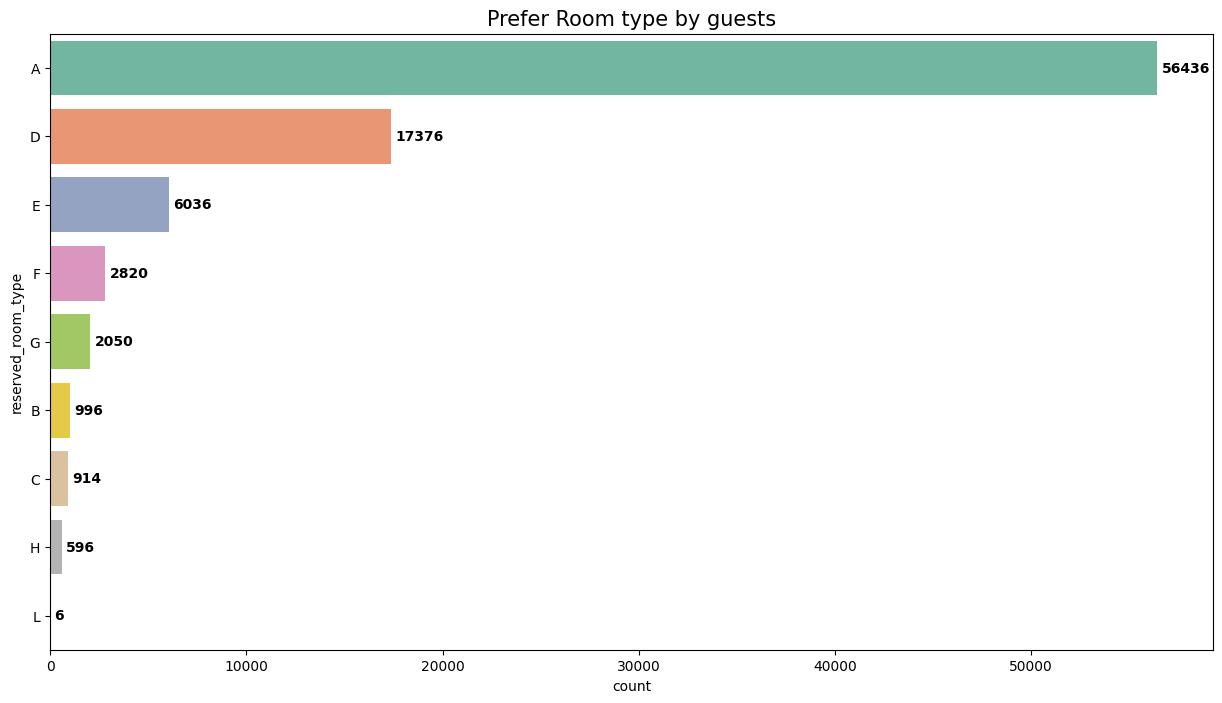

In [236]:
roomType=df1['reserved_room_type'].value_counts(ascending=False).reset_index()
fig,ax=plt.subplots(figsize=(15,8))

sns.barplot(data=roomType,
            y='reserved_room_type',
            x='count',
            hue='reserved_room_type',
            palette='Set2')

for container in ax.containers:
  ax.bar_label(container,fontsize=10,fontweight='bold',padding=3)

plt.title("Prefer Room type by guests", fontsize = 15)
plt.show()



---
By Observing the above chart we can understand that the room type **"A"** is most prefered by the guests while booking the hotel


### **Which room type is most assigned?**

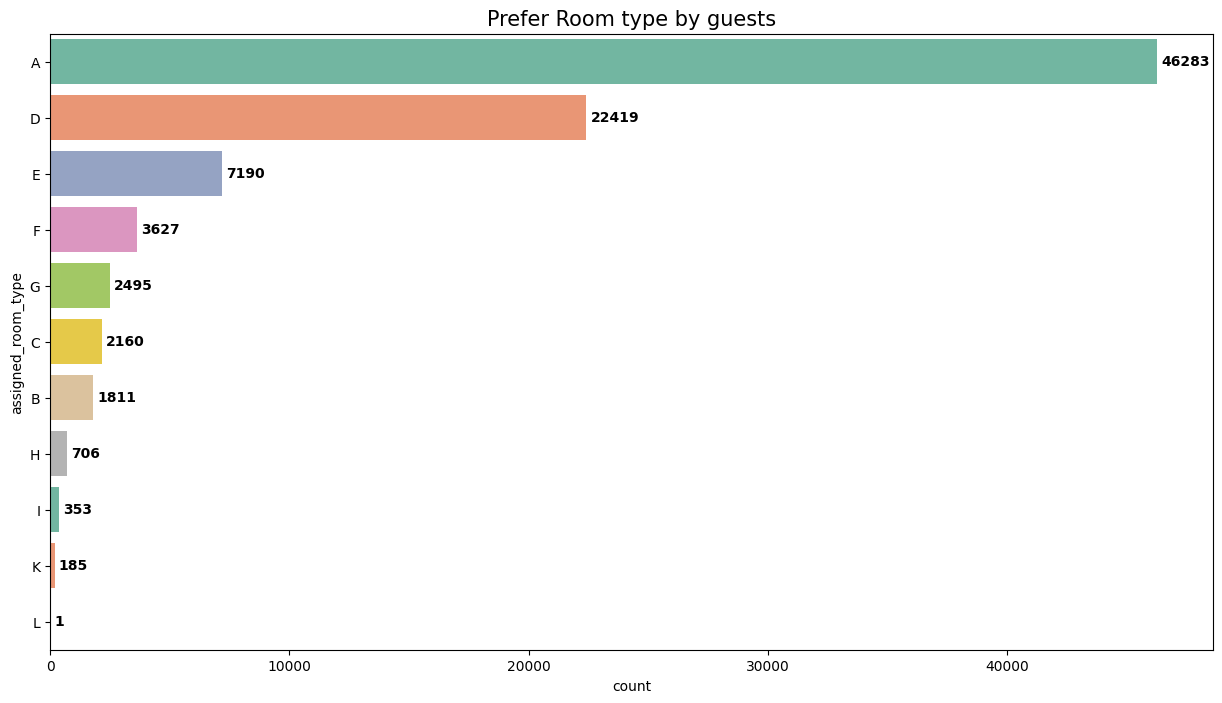

In [237]:
assignedRoomType=df1['assigned_room_type'].value_counts(ascending=False).reset_index()
fig,ax=plt.subplots(figsize=(15,8))

sns.barplot(data=assignedRoomType,
            y='assigned_room_type',
            x='count',
            hue='assigned_room_type',
            palette='Set2')

for container in ax.containers:
  ax.bar_label(container,fontsize=10,fontweight='bold',padding=3)

plt.title("Prefer Room type by guests", fontsize = 15)
plt.show()



---
From this above two chart we saw that around 56k guests prefferd room type A but 46k people were assigned A type room.This could be a reason to cancel the bookings.Hotel could increase A type room to decrease cancellation


### **Top 5 agents in term of most bookings?**

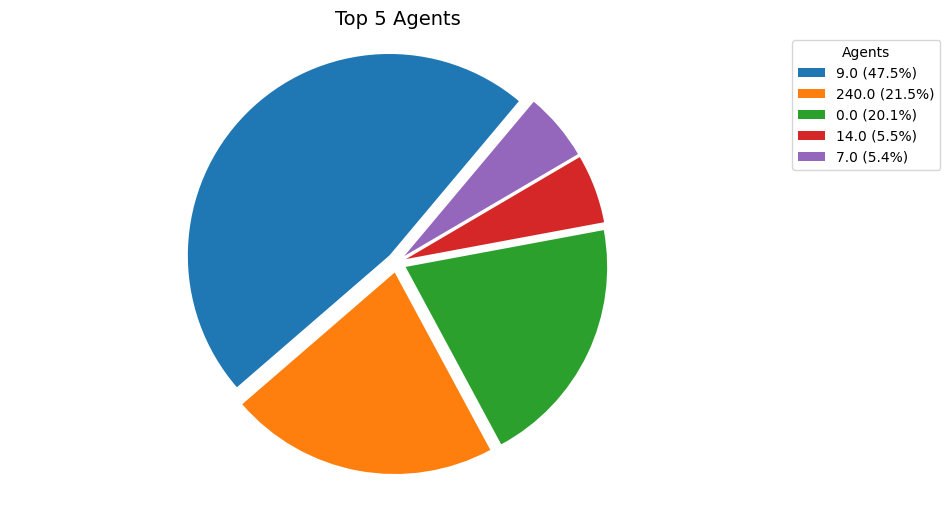

In [238]:
agents_df =df1['agent'].value_counts(ascending=False).head()
explode = [0.05] * len(agents_df)
plt.figure(figsize=(10,6))

plt.pie(
    agents_df.values,
    explode=explode,
    startangle=50
)

labels = [
    f"{name} ({count/agents_df.sum()*100:.1f}%)"
    for name, count in agents_df.items()
]

plt.legend(
    labels,
    title="Agents",
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

plt.title("Top 5 Agents", fontsize=14)
plt.axis('equal')
plt.show()




---
We can see that agent number 9 has made most number of bookings followed by agent number 240,0,14 and 7





### **What are the Percentage of repeated guests?**

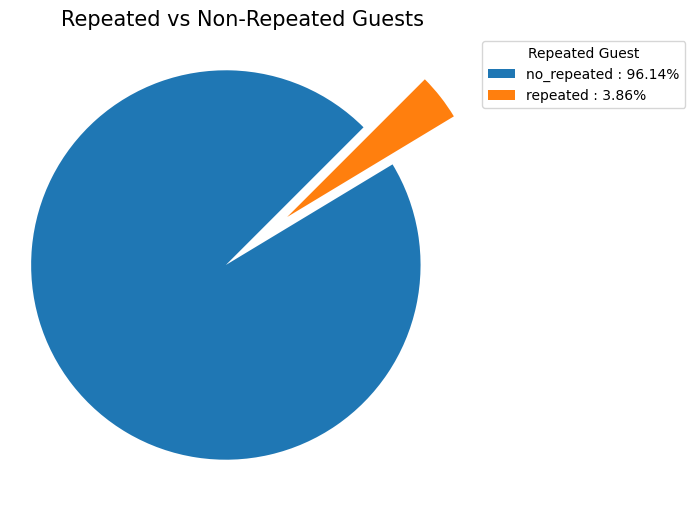

In [239]:
is_repeated=df1['is_repeated_guest'].value_counts().reset_index()

def percentage(is_repeated):
  is_repeated['percentage']=is_repeated['count']*100/is_repeated['count'].sum()
percentage(is_repeated)

is_repeated['is_repeated_guest']=is_repeated['is_repeated_guest'].map({1:'repeated',0:'no_repeated'})

plt.figure(figsize=(6,6))

plt.pie(is_repeated['percentage'],
        explode=[0.3,0.1],
        startangle=45)

labels = [
    f"{guest} : {perc:.2f}%"
    for guest, perc in zip(is_repeated['is_repeated_guest'], is_repeated['percentage'])
]

plt.legend(
    labels,
    loc='upper left',
    bbox_to_anchor=(1,1),
    title='Repeated Guest'
)

plt.title("Repeated vs Non-Repeated Guests",fontsize=15)
plt.axis('equal')
plt.show()


---
From this above chart we can see that 3.86% guests are repeated guests

---
We can see that the number of repeated guests is very low.Hotel can offer loyality discount to their guests to increase repeated guests

### **Which customer type has the most booking?**

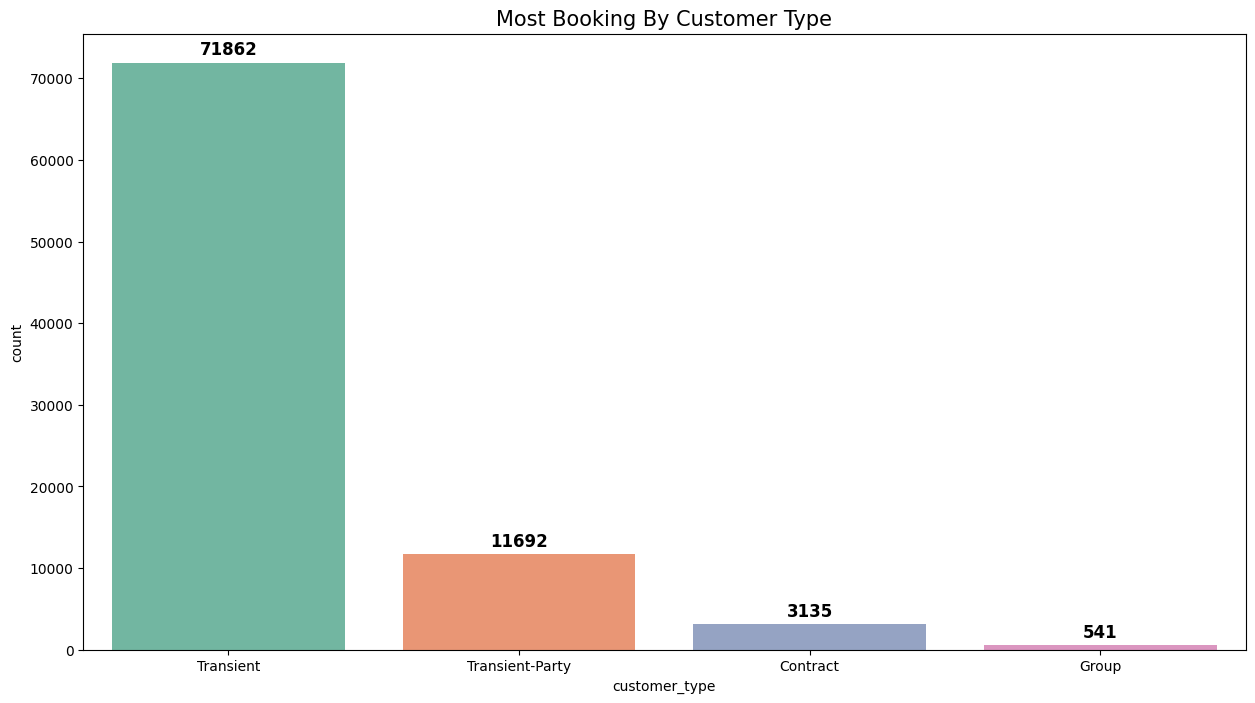

In [240]:
fig,ax=plt.subplots(figsize=(15,8))

most_booking=df1['customer_type'].value_counts(ascending=False).reset_index()

sns.barplot(x=most_booking['customer_type'],
            y=most_booking['count'],
            hue=most_booking['customer_type'],palette='Set2')

for container in ax.containers:
  ax.bar_label(container,padding=3,fontsize=12,
               fontweight='bold')

plt.title('Most Booking By Customer Type',fontsize=15)
plt.show()


---
We can see that the Transient customer type has most number of bookings

---
Hotel can give some offers for others categories to increase the bookings .Such as hotel could offer discounts for Groups

### **Which market segment has the most booking?**

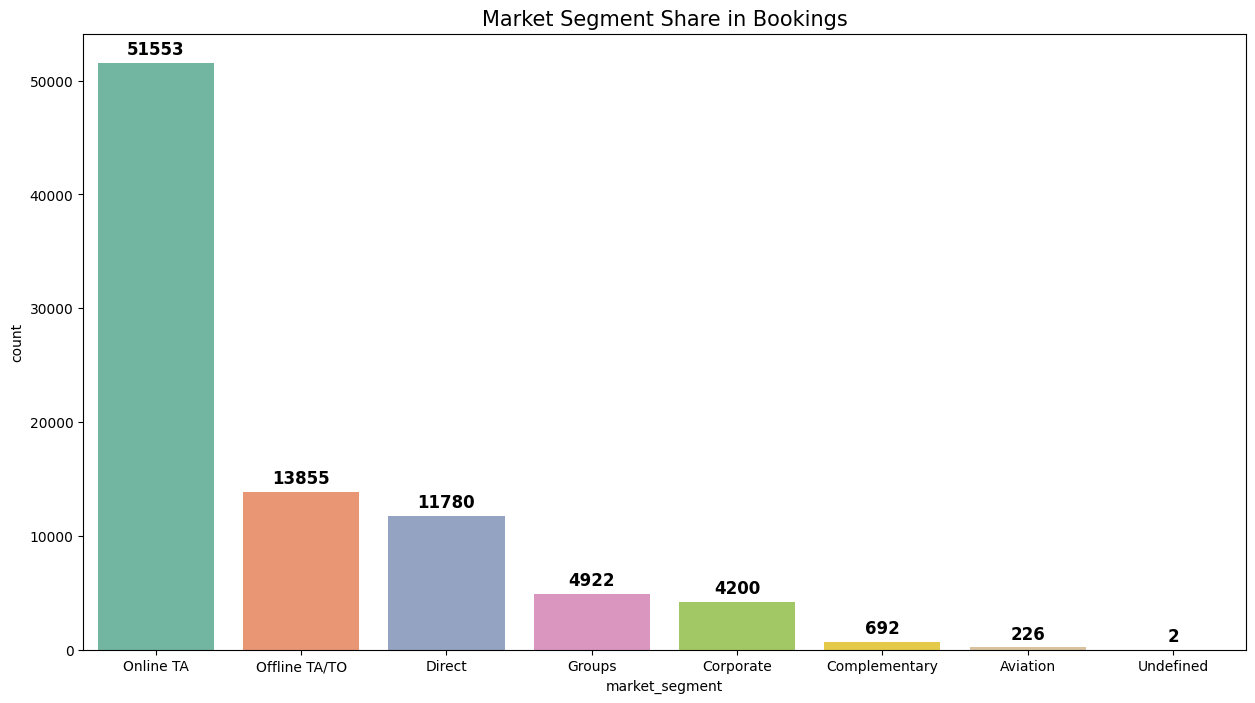

In [241]:
fig,ax=plt.subplots(figsize=(15,8))

market_seg=df1['market_segment'].value_counts(ascending=False).reset_index()

sns.barplot(x=market_seg['market_segment'],
            y=market_seg['count'],
            hue=market_seg['market_segment'],palette='Set2')

for container in ax.containers:
  ax.bar_label(container,padding=3,fontsize=12,
               fontweight='bold')

plt.title('Market Segment Share in Bookings',fontsize=15)
plt.show()

---
This above chart shows that Online TA(Travel Agent) has the most bookings

---
Hotel should come up with some great idea to increase share among other market segmets to generate more revenue

### **Whixh deposite type is most preffered?**

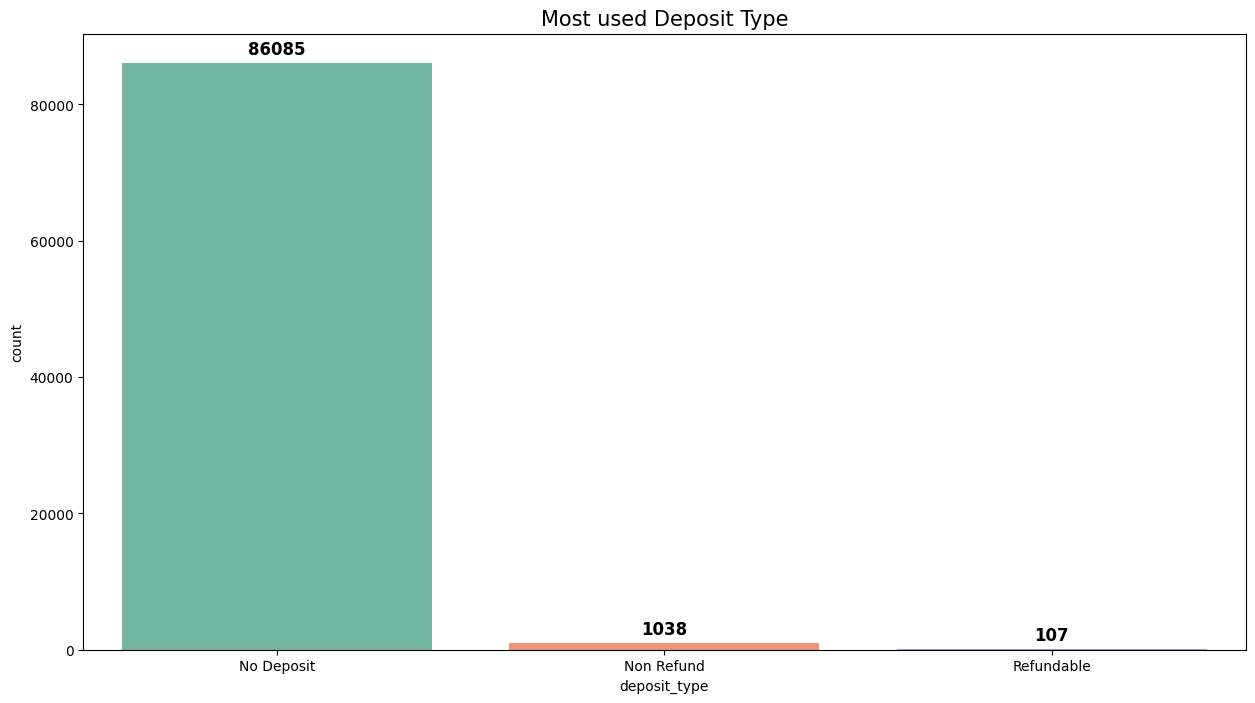

In [242]:
fig,ax=plt.subplots(figsize=(15,8))

deposit_Type=df1['deposit_type'].value_counts(ascending=False).reset_index()

sns.barplot(x=deposit_Type['deposit_type'],
            y=deposit_Type['count'],
            hue=deposit_Type['deposit_type'],palette='Set2')

for container in ax.containers:
  ax.bar_label(container,padding=3,fontsize=12,
               fontweight='bold')

plt.title('Most used Deposit Type',fontsize=15)
plt.show()

### **How long people stay in the Hotel?**

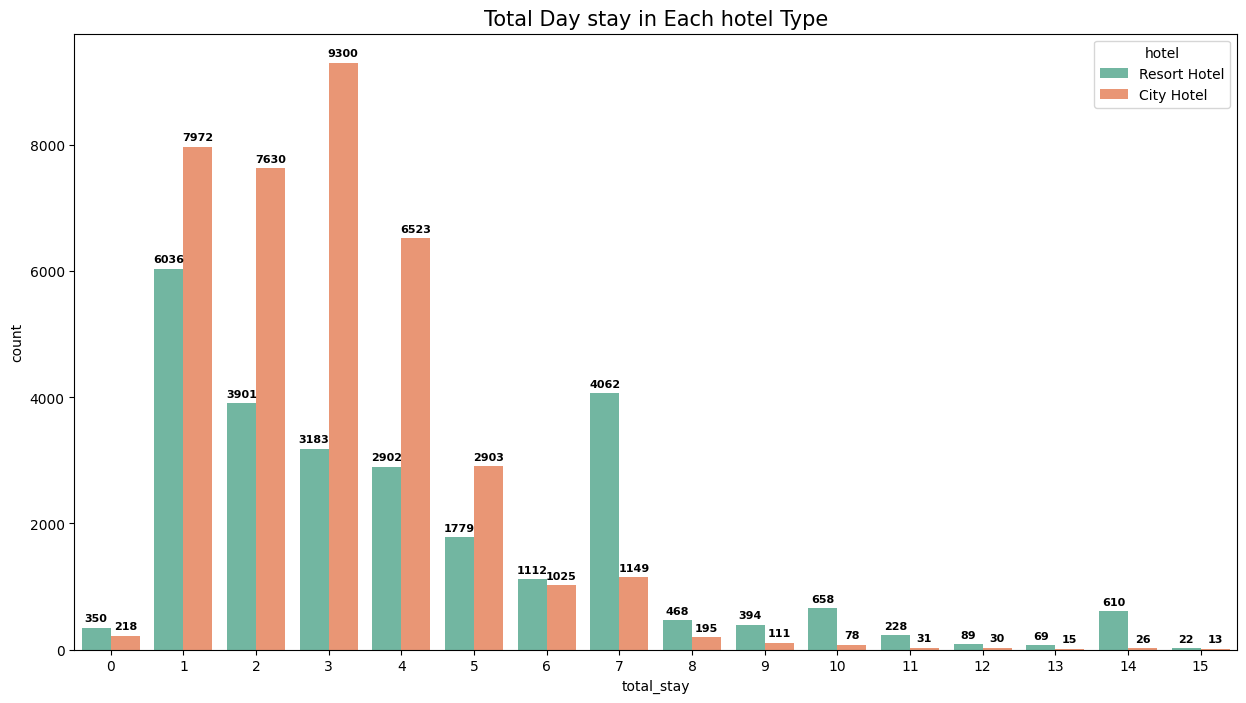

In [243]:
fig,ax=plt.subplots(figsize=(15,8))

not_cancelled_df=df1[df1['is_canceled']==0]

hotel_stay=not_cancelled_df[not_cancelled_df['total_stay']<=15]

sns.countplot(x=hotel_stay['total_stay'],
              hue=hotel_stay['hotel'],
    palette='Set2')

for container in ax.containers:
  ax.bar_label(container,padding=3,fontsize=8,
               fontweight='bold')

plt.title('Total Day stay in Each hotel Type',fontsize=15)
plt.show()

---
From this above chart we can see that in City hotel most peopele stay for 3 days and in resort hotel most people stay for only 1 day

---
Hotel should work on to increase total stay in Resort hotel to increse revenue

### **Which type of hotel generate more revenue?**

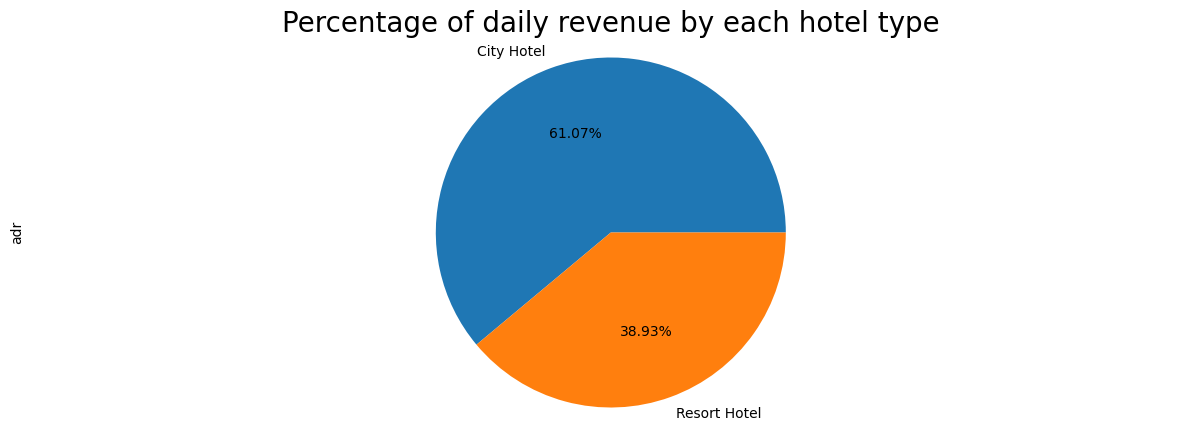

In [244]:
most_rev = df1.groupby('hotel')['adr'].count()

most_rev.plot.pie(autopct='%.2f%%', figsize=(15,5))
plt.title('Percentage of daily revenue by each hotel type', fontsize=20)

plt.axis('equal')
plt.show()

---
From this it is clear that City hotel generate more revenue compare to resort hotel.Stackholders must focus on Resort hotel so that people more stay in resort hotel.|

### **Which hotel has longer waiting time?**

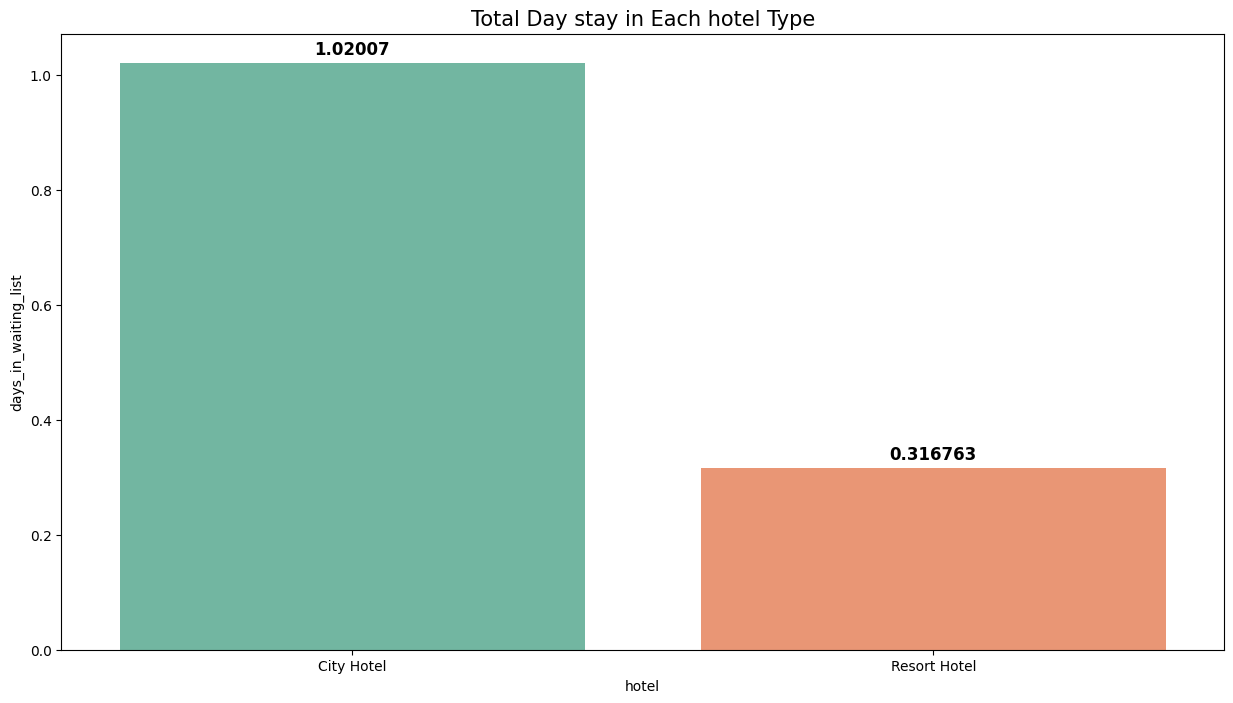

In [245]:
fig,ax=plt.subplots(figsize=(15,8))

wait_df=df1.groupby('hotel')['days_in_waiting_list'].mean().reset_index()

sns.barplot(x=wait_df['hotel'],
            y=wait_df['days_in_waiting_list'],
            hue=wait_df['hotel'],
            palette='Set2')

for container in ax.containers:
  ax.bar_label(container,padding=3,fontsize=12,
               fontweight='bold')

plt.title('Total Day stay in Each hotel Type',fontsize=15)
plt.show()



---
Above chart shows that city hotel has more waiting period.This could be because people stay more days in City hotel as we saw it our previous chart



###**Hotel with most repeated guests?**

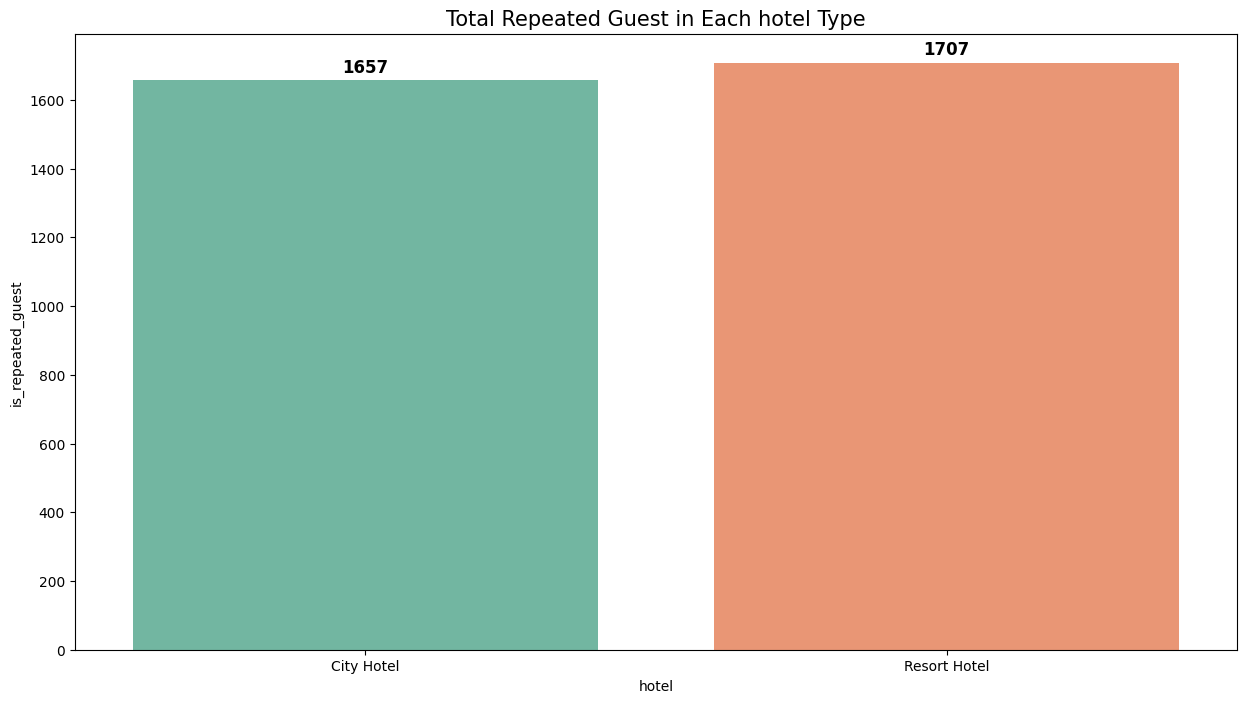

In [246]:
fig,ax=plt.subplots(figsize=(15,8))

rep_guest_df=df1[df1['is_repeated_guest']==1]

rep_guest=rep_guest_df.groupby('hotel')['is_repeated_guest'].count().reset_index()

sns.barplot(
    x=rep_guest['hotel'],
    y=rep_guest['is_repeated_guest'],
    hue=rep_guest['hotel'],
    palette='Set2'
)

for container in ax.containers:
  ax.bar_label(container,padding=3,fontsize=12,
               fontweight='bold')

plt.title('Total Repeated Guest in Each hotel Type',fontsize=15)
plt.show()

### **What is the average adr across different months?**

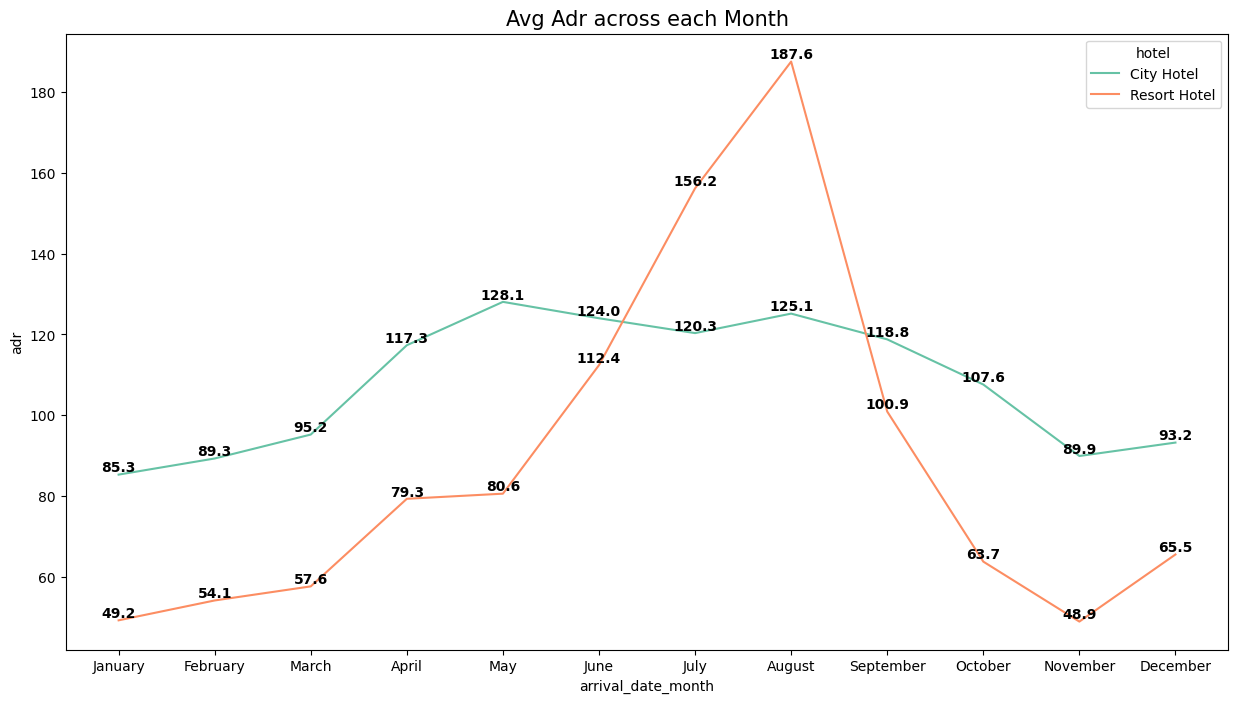

In [247]:
fig,ax=plt.subplots(figsize=(15,8))

avg_adr_month=df1.groupby(['arrival_date_month','hotel'],as_index=False)['adr'].mean()
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
avg_adr_month['arrival_date_month'] = pd.Categorical(
    avg_adr_month['arrival_date_month'],
    categories=month_order,
    ordered=True
)
sns.lineplot(x=avg_adr_month['arrival_date_month'],
            y=avg_adr_month['adr'],
            hue=avg_adr_month['hotel'],
             markers='o',
             palette='Set2',
             ax=ax)

for _, row in avg_adr_month.iterrows():
    ax.text(
        row['arrival_date_month'],
        row['adr'],
        f"{row['adr']:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Avg Adr across each Month',fontsize=15)
plt.show()

---
City Hotel generates more revenue in May months compare to other months

----
Resort Hotel generate more revenue Between July and Agusts Month

### **Which Distribution Channel has highest ADR?**

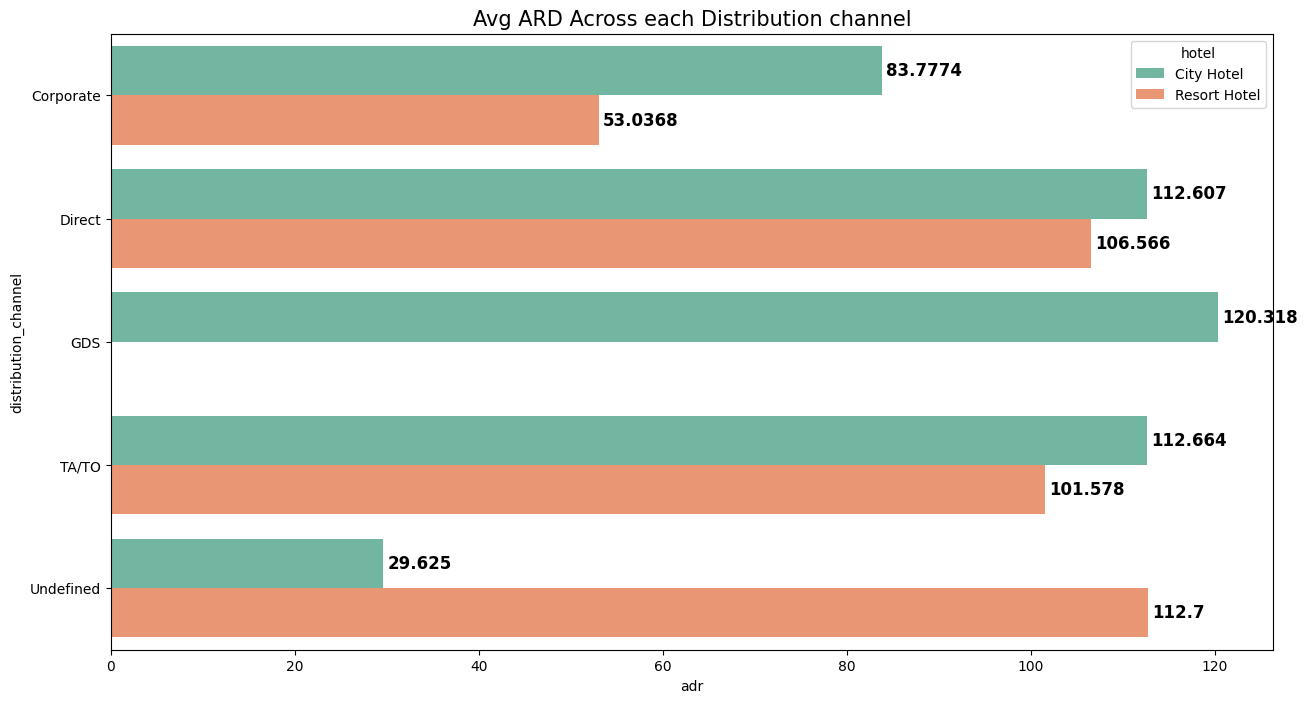

In [248]:
fig,ax=plt.subplots(figsize=(15,8))

high_dis=df1.groupby(['distribution_channel','hotel'])['adr'].mean().reset_index()

sns.barplot(
    data=high_dis,
    y='distribution_channel',
    x='adr',
    hue='hotel',
    palette='Set2'
)

for container in ax.containers:
  ax.bar_label(container,padding=3,fontsize=12,
               fontweight='bold')

plt.title('Avg ARD Across each Distribution channel',fontsize=15)
plt.show()

GDS has contributed more in generating the ADR. GDS is a worldwide conduit between travel bookers and suppliers, such as hotels and other accommodation providers. It communicates live product, price and availability data to travel agents and online booking engines, and allows for automated transactions.

Direct- means that bookings are directly made with the respective hotels

TA/TO- means that booings are made through travel agents or travel operators.

Undefined- Bookings are undefined. may be customers made their bookings on arrival.

### **Correlation Heatmap**

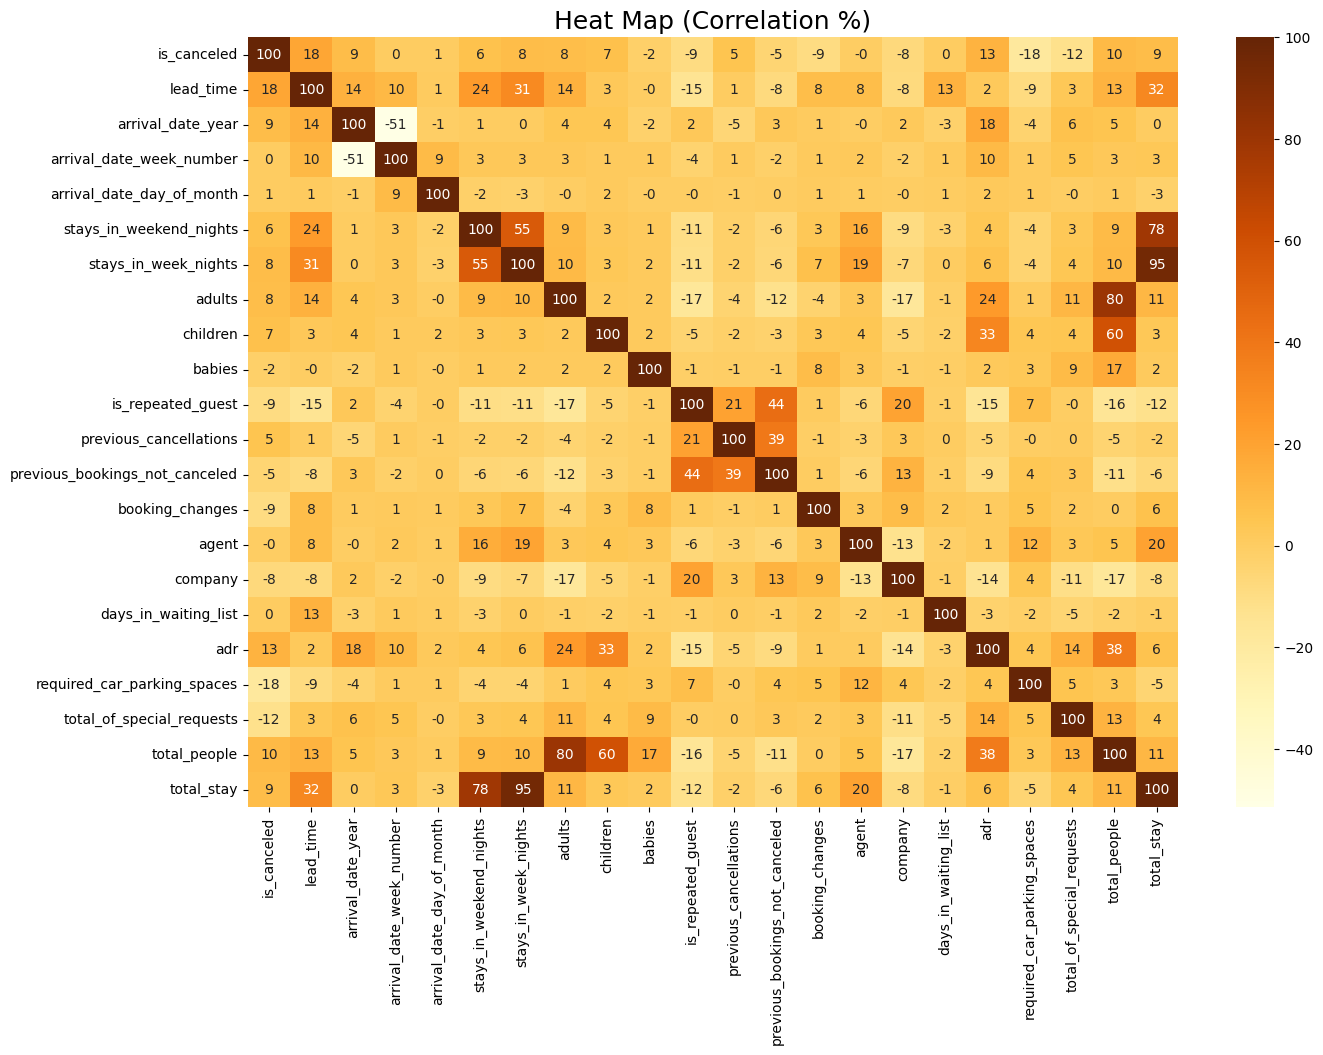

In [249]:
plt.figure(figsize=(15,10))

sns.heatmap(df1.corr(numeric_only=True)*100,
            annot=True,
            fmt=".0f",
            cmap='YlOrBr')
plt.title('Heat Map (Correlation %)', fontsize=18)
plt.show()



---
From this above heat map
1) lead_time and total_stay is positively corelated. that means if customers stay more then the lead time increases.

2) adults,childrens and babies are corelated to each other. That means more the people more will be adr.

3) is_repeated guest and previous bookings not canceled has strong corelation. That means repeated guests don't cancel their bookings.**

## Recommendations for Stakeholders
1.  **Strategic Cancellation Management:** For City Hotels, investigate the root causes of higher cancellations and implement dynamic pricing, flexible cancellation policies, or personalized retention offers.
2.  **Optimize Seasonal Strategies:** Leverage peak booking months (July/August) with targeted promotions. Analyze the reasons for the booking drop in 2017 to recover and sustain growth. Develop attractive packages for off-peak seasons.
3.  **Targeted Marketing:** Focus marketing efforts on key demographics, especially the Portuguese market, and consider integrating cultural preferences into services. Continue to highlight the popular 'BB' meal plan.
4.  **Enhance Booking Channel & Room Allocation:** Strengthen partnerships with high-performing travel agents (e.g., Agent #9). Address the discrepancy between reserved and assigned room types to improve guest satisfaction and reduce potential cancellations.
5.  **Boost Resort Hotel Stays & Revenue:** Implement strategies to encourage longer stays in Resort Hotels, such as value-added packages or activity bundles. Analyze and adjust pricing (ADR) based on seasonal demand and distribution channel performance (noting GDS's high ADR).
6.  **Cultivate Guest Loyalty:** Introduce and actively promote a comprehensive loyalty program offering exclusive benefits (discounts, upgrades, personalized services) to increase the low rate of repeated guests.
